<a href="https://colab.research.google.com/github/thimeshaA/BrineXCompass-M2-Demand-PriceForecasting/blob/main/SARIMAXv2_for_demand_and_price.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/


✅ Loaded 168 months  (2012-01 → 2025-12)
⚠️  5 months hit the 95,000 demand cap (3.0% of data)

CORRECTED ROLLING 2-MONTH BACKTEST (2023 onwards)
Running 34 origin points from 2023-01-01...
   8/34 done...
   16/34 done...
   24/34 done...
   32/34 done...

✅ Backtest complete. 34 month+1 windows, 34 month+2 windows

HONEST EVALUATION RESULTS

                           Month+1      Month+2
  ─────────────────────────────────────────────
  Demand MAPE (all):        18.34%       23.33%
  Demand MAPE (no cap):     17.11%       21.66%   ← most honest
  Price MAPE:                1.16%        1.35%
  ─────────────────────────────────────────────
  Capped months in eval:     3            4
  Total windows:            34           34
  Directional Acc (demand):  44.8%

  ⚠️  DEMAND month+1: moderate — use with margin
  ⚠️  DEMAND month+2: moderate
  ✅ PRICE: excellent accuracy

RETRAINING ON FULL DATA (production model)
✅ Demand  AIC=2461.0
✅ Price   AIC=1242.6

✅ Saved: /content/drive/MyDri

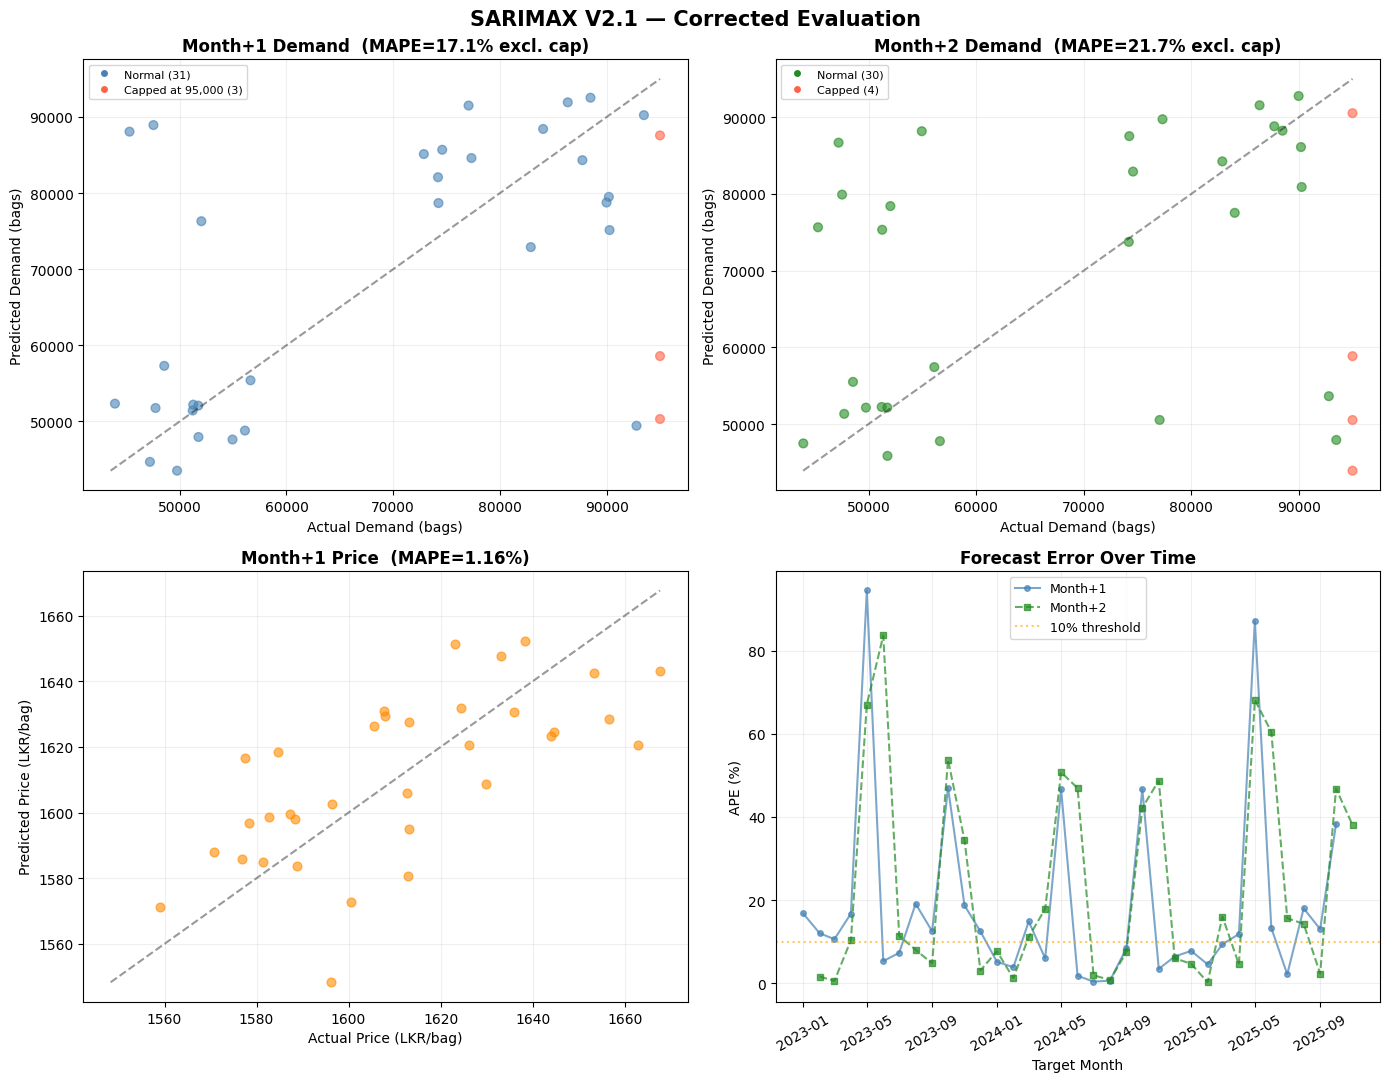

✅ Plot saved

🎉 SARIMAX V2.1 PRODUCTION MODEL READY

📊 MODEL: SARIMA(1, 1, 1)x(1, 1, 1, 12) (demand)
          SARIMA(1, 1, 1)x(0, 1, 1, 12) (price)
   Features: lag_12m, lag_1m, supply_ratio, production_bags, is_maha

🎯 HONEST PERFORMANCE (leakage-free, 34 windows from 2023):
   Demand Month+1:  18.34% all  |  17.11% excl. capped months
   Demand Month+2:  23.33% all  |  21.66% excl. capped months
   Price  Month+1:  1.16%
   Price  Month+2:  1.35%
   Directional:     44.8%

📁 ARTIFACTS SAVED TO: /content/drive/MyDrive/BrineXCompass/models-Compass
   sarimax_v2_model.pkl   ← load in FastAPI service
   sarimax_v2_meta.json   ← lightweight metadata

⚠️  DEPLOYMENT NOTE:
   At inference, pass demand_lag_1m = last known actual demand
   For month+2, the service automatically uses month+1 prediction as lag.
   supply_ratio and production_bags = latest values from your production system.



In [ ]:
# ==============================================================================
# SARIMAX V2.1 — CORRECTED: No Data Leakage, Proper Real-World Evaluation
#
# WHAT CHANGED FROM V2:
#   ISSUE 1 — DATA LEAKAGE in rolling eval
#     V2 used test_df[demand_exog_cols] directly, which gave the model
#     actual demand_lag_1m values for BOTH months in each 2-month window.
#     In reality, for month+2 you only have the month+1 PREDICTION, not actual.
#     Fix: for each window, manually build exog using predicted month+1 as lag.
#
#   ISSUE 2 — 95000 DEMAND CAP
#     Some months hit a hard ceiling of 95,000 bags. Any model trivially
#     predicts these correctly by learning the seasonal pattern.
#     Fix: report MAPE on non-capped months separately for honest accuracy.
#
#   ISSUE 3 — Test window too short + too recent
#     12-month test window (2025 only) was heavy on cap months (4 of 12).
#     Fix: extend backtest to 2023 onwards for a more representative sample.
# ==============================================================================

import pandas as pd
import numpy as np
import pickle
import json
from pathlib import Path
from statsmodels.tsa.statespace.sarimax import SARIMAX
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

BASE_PATH = '/content/drive/MyDrive/BrineXCompass'
MODELS_DIR = Path(f'{BASE_PATH}/models-Compass')
MODELS_DIR.mkdir(exist_ok=True)

DEMAND_ORDER   = (1, 1, 1)
DEMAND_SEAS    = (1, 1, 1, 12)
PRICE_ORDER    = (1, 1, 1)
PRICE_SEAS     = (0, 1, 1, 12)

DEMAND_EXOG = ['is_maha_season', 'demand_lag_12m', 'demand_lag_1m', 'demand_supply_ratio', 'total_production_bags']
PRICE_EXOG  = ['is_maha_season', 'price_lag_12m',  'price_lag_1m',  'total_production_bags']

# Demand cap — months at this value are easy to predict and skew MAPE
DEMAND_CAP = 95000

# ==============================================================================
# LOAD
# ==============================================================================

df = pd.read_excel(f'{BASE_PATH}/monthly_aggregates_sarimax.xlsx')
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)
df = df.set_index('date')
df = df.asfreq('MS')

print(f"✅ Loaded {len(df)} months  ({df.index[0].strftime('%Y-%m')} → {df.index[-1].strftime('%Y-%m')})")
cap_count = (df['total_monthly_demand'] == DEMAND_CAP).sum()
print(f"⚠️  {cap_count} months hit the {DEMAND_CAP:,} demand cap ({cap_count/len(df)*100:.1f}% of data)")

def safe_mape(y_true, y_pred, exclude_capped=False):
    a, p = np.array(y_true, dtype=float), np.array(y_pred, dtype=float)
    mask = (np.abs(a) > 1) & np.isfinite(a) & np.isfinite(p)
    if exclude_capped:
        mask = mask & (a < DEMAND_CAP)
    if mask.sum() == 0:
        return np.nan
    return float(np.mean(np.abs((a[mask] - p[mask]) / a[mask])) * 100)

def get_is_maha(month: int) -> int:
    return 1 if month in [10, 11, 12, 1, 2, 3] else 0

# ==============================================================================
# PROPER ROLLING 2-MONTH EVALUATION — no leakage
# ==============================================================================
# For each origin month:
#   - Train on data up to origin
#   - Forecast month+1: exog uses actual lag_1m = last known month ✅
#   - Forecast month+2: exog uses PREDICTED month+1 as lag_1m (not actual) ✅
#   - demand_lag_12m is always actual (it's from 12 months ago, always known) ✅
#   - demand_supply_ratio and total_production_bags: use last known ✅
#     (at inference time you'd use the latest available values from your production system)

print("\n" + "=" * 70)
print("CORRECTED ROLLING 2-MONTH BACKTEST (2023 onwards)")
print("=" * 70)

# Backtest from 2023 (gives 24+ months of evaluation windows)
BACKTEST_START = '2023-01-01'
backtest_start_idx = df.index.get_loc(pd.Timestamp(BACKTEST_START))

demand_results_m1, demand_results_m2 = [], []
price_results_m1,  price_results_m2  = [], []

n_origins = len(df) - backtest_start_idx - 2
print(f"Running {n_origins} origin points from {BACKTEST_START}...")

for i in range(n_origins):
    origin_idx  = backtest_start_idx + i
    origin_date = df.index[origin_idx]

    train    = df.iloc[:origin_idx]
    actual_m1 = df.iloc[origin_idx]
    actual_m2 = df.iloc[origin_idx + 1]

    if len(train) < 24:
        continue

    # ---- Build exog for month+1 ----
    # lag_1m = last actual demand (the month before origin)
    last_actual = train.iloc[-1]

    m1_date = df.index[origin_idx]
    m1_lag12_row = train[train.index <= (m1_date - pd.DateOffset(months=12))]
    m1_d_lag12 = float(m1_lag12_row.iloc[-1]['total_monthly_demand']) if len(m1_lag12_row) > 0 else float(train['total_monthly_demand'].mean())
    m1_p_lag12 = float(m1_lag12_row.iloc[-1]['price_mean']) if len(m1_lag12_row) > 0 else float(train['price_mean'].mean())

    d_exog_m1 = np.array([[
        get_is_maha(m1_date.month),
        m1_d_lag12,
        float(last_actual['total_monthly_demand']),  # lag_1m = last known actual ✅
        float(last_actual['demand_supply_ratio']),
        float(last_actual['total_production_bags']),
    ]], dtype=float)

    p_exog_m1 = np.array([[
        get_is_maha(m1_date.month),
        m1_p_lag12,
        float(last_actual['price_mean']),            # lag_1m = last known actual ✅
        float(last_actual['total_production_bags']),
    ]], dtype=float)

    try:
        # Fit demand model
        dm = SARIMAX(
            train['total_monthly_demand'].astype(float).values,
            exog=train[DEMAND_EXOG].astype(float).values,
            order=DEMAND_ORDER, seasonal_order=DEMAND_SEAS,
            enforce_stationarity=False, enforce_invertibility=False
        )
        d_fit = dm.fit(disp=False, maxiter=300)

        # Fit price model
        pm = SARIMAX(
            train['price_mean'].astype(float).values,
            exog=train[PRICE_EXOG].astype(float).values,
            order=PRICE_ORDER, seasonal_order=PRICE_SEAS,
            enforce_stationarity=False, enforce_invertibility=False
        )
        p_fit = pm.fit(disp=False, maxiter=300)

        # --- Forecast month+1 ---
        d_fc1 = d_fit.get_forecast(steps=1, exog=d_exog_m1)
        p_fc1 = p_fit.get_forecast(steps=1, exog=p_exog_m1)
        d_pred_m1 = float(np.clip(d_fc1.predicted_mean[0], 0, None))
        p_pred_m1 = float(p_fc1.predicted_mean[0])

        demand_results_m1.append({
            'origin': origin_date, 'target': m1_date,
            'actual': float(actual_m1['total_monthly_demand']),
            'predicted': d_pred_m1,
            'is_capped': actual_m1['total_monthly_demand'] >= DEMAND_CAP
        })
        price_results_m1.append({
            'origin': origin_date, 'target': m1_date,
            'actual': float(actual_m1['price_mean']),
            'predicted': p_pred_m1,
        })

        # --- Build exog for month+2 — use month+1 PREDICTION as lag_1m ✅ ---
        m2_date = df.index[origin_idx + 1]
        m2_lag12_row = train[train.index <= (m2_date - pd.DateOffset(months=12))]
        m2_d_lag12 = float(m2_lag12_row.iloc[-1]['total_monthly_demand']) if len(m2_lag12_row) > 0 else float(train['total_monthly_demand'].mean())
        m2_p_lag12 = float(m2_lag12_row.iloc[-1]['price_mean']) if len(m2_lag12_row) > 0 else float(train['price_mean'].mean())

        d_exog_m2 = np.array([[
            get_is_maha(m2_date.month),
            m2_d_lag12,
            d_pred_m1,   # ← month+1 PREDICTION, not actual ✅ no leakage
            float(last_actual['demand_supply_ratio']),
            float(last_actual['total_production_bags']),
        ]], dtype=float)

        p_exog_m2 = np.array([[
            get_is_maha(m2_date.month),
            m2_p_lag12,
            p_pred_m1,   # ← month+1 PREDICTION, not actual ✅ no leakage
            float(last_actual['total_production_bags']),
        ]], dtype=float)

        # Build 2-step exog for a single get_forecast call
        d_exog_both = np.vstack([d_exog_m1, d_exog_m2])
        p_exog_both = np.vstack([p_exog_m1, p_exog_m2])

        d_fc2 = d_fit.get_forecast(steps=2, exog=d_exog_both)
        p_fc2 = p_fit.get_forecast(steps=2, exog=p_exog_both)

        d_pred_m2 = float(np.clip(d_fc2.predicted_mean[1], 0, None))
        p_pred_m2 = float(p_fc2.predicted_mean[1])

        demand_results_m2.append({
            'origin': origin_date, 'target': m2_date,
            'actual': float(actual_m2['total_monthly_demand']),
            'predicted': d_pred_m2,
            'is_capped': actual_m2['total_monthly_demand'] >= DEMAND_CAP
        })
        price_results_m2.append({
            'origin': origin_date, 'target': m2_date,
            'actual': float(actual_m2['price_mean']),
            'predicted': p_pred_m2,
        })

    except:
        pass

    if (i + 1) % 8 == 0:
        print(f"   {i+1}/{n_origins} done...")

print(f"\n✅ Backtest complete. {len(demand_results_m1)} month+1 windows, {len(demand_results_m2)} month+2 windows\n")

# ==============================================================================
# RESULTS — HONEST METRICS
# ==============================================================================

print("=" * 70)
print("HONEST EVALUATION RESULTS")
print("=" * 70)

# Month+1
d_m1_all    = safe_mape([r['actual'] for r in demand_results_m1], [r['predicted'] for r in demand_results_m1])
d_m1_nocap  = safe_mape([r['actual'] for r in demand_results_m1], [r['predicted'] for r in demand_results_m1], exclude_capped=True)
p_m1_all    = safe_mape([r['actual'] for r in price_results_m1],  [r['predicted'] for r in price_results_m1])

# Month+2
d_m2_all    = safe_mape([r['actual'] for r in demand_results_m2], [r['predicted'] for r in demand_results_m2])
d_m2_nocap  = safe_mape([r['actual'] for r in demand_results_m2], [r['predicted'] for r in demand_results_m2], exclude_capped=True)
p_m2_all    = safe_mape([r['actual'] for r in price_results_m2],  [r['predicted'] for r in price_results_m2])

# Directional accuracy
m1_a = [r['actual'] for r in demand_results_m1]
m1_p = [r['predicted'] for r in demand_results_m1]
m2_a = [r['actual'] for r in demand_results_m2]
m2_p = [r['predicted'] for r in demand_results_m2]
combined_actual = m1_a + m2_a
combined_pred   = m1_p + m2_p
dir_acc = float(np.mean(np.sign(np.diff(combined_actual)) == np.sign(np.diff(combined_pred))) * 100)

cap_count_m1 = sum(1 for r in demand_results_m1 if r['is_capped'])
cap_count_m2 = sum(1 for r in demand_results_m2 if r['is_capped'])

print(f"""
                           Month+1      Month+2
  ─────────────────────────────────────────────
  Demand MAPE (all):       {d_m1_all:>6.2f}%      {d_m2_all:>6.2f}%
  Demand MAPE (no cap):    {d_m1_nocap:>6.2f}%      {d_m2_nocap:>6.2f}%   ← most honest
  Price MAPE:              {p_m1_all:>6.2f}%      {p_m2_all:>6.2f}%
  ─────────────────────────────────────────────
  Capped months in eval:   {cap_count_m1:>3}          {cap_count_m2:>3}
  Total windows:           {len(demand_results_m1):>3}          {len(demand_results_m2):>3}
  Directional Acc (demand):{dir_acc:>6.1f}%
""")

if d_m1_nocap < 10:
    print("  ✅ DEMAND month+1: reliable for operational decisions")
elif d_m1_nocap < 15:
    print("  ✅ DEMAND month+1: good for planning")
else:
    print("  ⚠️  DEMAND month+1: moderate — use with margin")

if d_m2_nocap < 10:
    print("  ✅ DEMAND month+2: reliable for planning")
elif d_m2_nocap < 15:
    print("  ✅ DEMAND month+2: acceptable")
else:
    print("  ⚠️  DEMAND month+2: moderate")

if p_m1_all < 3:
    print("  ✅ PRICE: excellent accuracy")

# ==============================================================================
# RETRAIN ON FULL DATA
# ==============================================================================

print("\n" + "=" * 70)
print("RETRAINING ON FULL DATA (production model)")
print("=" * 70)

demand_final = SARIMAX(
    df['total_monthly_demand'].astype(float).values,
    exog=df[DEMAND_EXOG].astype(float).values,
    order=DEMAND_ORDER, seasonal_order=DEMAND_SEAS,
    enforce_stationarity=False, enforce_invertibility=False
).fit(disp=False, maxiter=500)
print(f"✅ Demand  AIC={demand_final.aic:.1f}")

price_final = SARIMAX(
    df['price_mean'].astype(float).values,
    exog=df[PRICE_EXOG].astype(float).values,
    order=PRICE_ORDER, seasonal_order=PRICE_SEAS,
    enforce_stationarity=False, enforce_invertibility=False
).fit(disp=False, maxiter=500)
print(f"✅ Price   AIC={price_final.aic:.1f}")

# ==============================================================================
# SAVE ARTIFACTS
# ==============================================================================

history = df[['total_monthly_demand', 'price_mean', 'is_maha_season',
              'total_production_bags', 'demand_supply_ratio']].tail(24).copy()

model_bundle = {
    'demand_model': demand_final,
    'price_model':  price_final,
    'demand_order': DEMAND_ORDER,
    'demand_seasonal_order': DEMAND_SEAS,
    'price_order':  PRICE_ORDER,
    'price_seasonal_order': PRICE_SEAS,
    'demand_exog_cols': DEMAND_EXOG,
    'price_exog_cols':  PRICE_EXOG,
    'last_known_data':  history,
    'last_data_date':   df.index[-1],
    'demand_cap':       DEMAND_CAP,
    'performance': {
        'demand_m1_mape_all':   round(d_m1_all, 2),
        'demand_m1_mape_nocap': round(d_m1_nocap, 2),
        'demand_m2_mape_all':   round(d_m2_all, 2),
        'demand_m2_mape_nocap': round(d_m2_nocap, 2),
        'price_m1_mape':        round(p_m1_all, 2),
        'price_m2_mape':        round(p_m2_all, 2),
        'directional_accuracy': round(dir_acc, 1),
        'evaluation_windows_m1': len(demand_results_m1),
        'evaluation_windows_m2': len(demand_results_m2),
    },
    'metadata': {
        'version': 'sarimax_v2.1',
        'forecast_horizon': 2,
        'leakage_fix': 'month+2 uses predicted lag_1m not actual',
        'cap_note': f'Demand capped at {DEMAND_CAP}. Report nocap MAPE as primary metric.',
        'total_samples': len(df),
        'training_date': pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S'),
    }
}

bundle_path = MODELS_DIR / 'sarimax_v2_model.pkl'
with open(bundle_path, 'wb') as f:
    pickle.dump(model_bundle, f)
print(f"\n✅ Saved: {bundle_path}")

meta_out = {
    'version': 'sarimax_v2.1',
    'forecast_horizon': 2,
    'last_data_date': df.index[-1].strftime('%Y-%m-%d'),
    'demand_exog_cols': DEMAND_EXOG,
    'price_exog_cols':  PRICE_EXOG,
    'performance': model_bundle['performance'],
}
with open(MODELS_DIR / 'sarimax_v2_meta.json', 'w') as f:
    json.dump(meta_out, f, indent=2)
print(f"✅ Saved: {MODELS_DIR}/sarimax_v2_meta.json")

# ==============================================================================
# VISUALISATION — actual vs predicted scatter by horizon
# ==============================================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 11))
fig.suptitle('SARIMAX V2.1 — Corrected Evaluation', fontsize=15, fontweight='bold')

# Month+1 demand scatter
ax = axes[0, 0]
m1_actuals = [r['actual'] for r in demand_results_m1]
m1_preds   = [r['predicted'] for r in demand_results_m1]
colors_m1  = ['tomato' if r['is_capped'] else 'steelblue' for r in demand_results_m1]
ax.scatter(m1_actuals, m1_preds, c=colors_m1, alpha=0.6, s=40)
mn, mx = min(m1_actuals + m1_preds), max(m1_actuals + m1_preds)
ax.plot([mn, mx], [mn, mx], 'k--', alpha=0.4)
ax.set_xlabel('Actual Demand (bags)')
ax.set_ylabel('Predicted Demand (bags)')
ax.set_title(f'Month+1 Demand  (MAPE={d_m1_nocap:.1f}% excl. cap)', fontweight='bold')
ax.legend(handles=[
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='steelblue', label=f'Normal ({len(m1_actuals)-cap_count_m1})'),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='tomato', label=f'Capped at {DEMAND_CAP:,} ({cap_count_m1})')
], fontsize=8)
ax.grid(True, alpha=0.2)

# Month+2 demand scatter
ax = axes[0, 1]
m2_actuals = [r['actual'] for r in demand_results_m2]
m2_preds   = [r['predicted'] for r in demand_results_m2]
colors_m2  = ['tomato' if r['is_capped'] else 'forestgreen' for r in demand_results_m2]
ax.scatter(m2_actuals, m2_preds, c=colors_m2, alpha=0.6, s=40)
mn, mx = min(m2_actuals + m2_preds), max(m2_actuals + m2_preds)
ax.plot([mn, mx], [mn, mx], 'k--', alpha=0.4)
ax.set_xlabel('Actual Demand (bags)')
ax.set_ylabel('Predicted Demand (bags)')
ax.set_title(f'Month+2 Demand  (MAPE={d_m2_nocap:.1f}% excl. cap)', fontweight='bold')
ax.legend(handles=[
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='forestgreen', label=f'Normal ({len(m2_actuals)-cap_count_m2})'),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='tomato', label=f'Capped ({cap_count_m2})')
], fontsize=8)
ax.grid(True, alpha=0.2)

# Price scatter
ax = axes[1, 0]
p_actuals = [r['actual'] for r in price_results_m1]
p_preds   = [r['predicted'] for r in price_results_m1]
ax.scatter(p_actuals, p_preds, color='darkorange', alpha=0.6, s=40)
mn, mx = min(p_actuals + p_preds), max(p_actuals + p_preds)
ax.plot([mn, mx], [mn, mx], 'k--', alpha=0.4)
ax.set_xlabel('Actual Price (LKR/bag)')
ax.set_ylabel('Predicted Price (LKR/bag)')
ax.set_title(f'Month+1 Price  (MAPE={p_m1_all:.2f}%)', fontweight='bold')
ax.grid(True, alpha=0.2)

# Error over time
ax = axes[1, 1]
m1_dates  = [r['target'] for r in demand_results_m1]
m1_errors = [abs(r['actual'] - r['predicted']) / r['actual'] * 100 for r in demand_results_m1]
m2_dates  = [r['target'] for r in demand_results_m2]
m2_errors = [abs(r['actual'] - r['predicted']) / r['actual'] * 100 for r in demand_results_m2]
ax.plot(m1_dates, m1_errors, 'o-', color='steelblue', alpha=0.7, label='Month+1', markersize=4)
ax.plot(m2_dates, m2_errors, 's--', color='forestgreen', alpha=0.7, label='Month+2', markersize=4)
ax.axhline(10, color='orange', linestyle=':', alpha=0.6, label='10% threshold')
ax.set_xlabel('Target Month')
ax.set_ylabel('APE (%)')
ax.set_title('Forecast Error Over Time', fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.2)
ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig(MODELS_DIR / 'sarimax_v2_1_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Plot saved")

# ==============================================================================
# FINAL SUMMARY
# ==============================================================================
print(f"""
{'='*70}
🎉 SARIMAX V2.1 PRODUCTION MODEL READY
{'='*70}

📊 MODEL: SARIMA{DEMAND_ORDER}x{DEMAND_SEAS} (demand)
          SARIMA{PRICE_ORDER}x{PRICE_SEAS} (price)
   Features: lag_12m, lag_1m, supply_ratio, production_bags, is_maha

🎯 HONEST PERFORMANCE (leakage-free, {len(demand_results_m1)} windows from 2023):
   Demand Month+1:  {d_m1_all:.2f}% all  |  {d_m1_nocap:.2f}% excl. capped months
   Demand Month+2:  {d_m2_all:.2f}% all  |  {d_m2_nocap:.2f}% excl. capped months
   Price  Month+1:  {p_m1_all:.2f}%
   Price  Month+2:  {p_m2_all:.2f}%
   Directional:     {dir_acc:.1f}%

📁 ARTIFACTS SAVED TO: {MODELS_DIR}
   sarimax_v2_model.pkl   ← load in FastAPI service
   sarimax_v2_meta.json   ← lightweight metadata

⚠️  DEPLOYMENT NOTE:
   At inference, pass demand_lag_1m = last known actual demand
   For month+2, the service automatically uses month+1 prediction as lag.
   supply_ratio and production_bags = latest values from your production system.
""")